# 03 · What EO inputs recover under weak labels: the U-Net arm experiments

Controlled experiments on flood-state representation under weak, sensor-dependent supervision. U2b (+W_pre) is a diagnostic upper bound: W_pre is also a label ingredient.

**Reading rules.** Every model number is *agreement with weak reference labels*, never flood-mapping accuracy. "Not observed is not dry." Areas carry their semantics (observed_S1 / mapped_UNet / terrain_reconstructed / literature_reported). Evidence levels: independent_physical › cross_sensor › weak_label_agreement › contextual.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "case_studies/kakhovka_2023/tables").exists())
CS = ROOT / "case_studies/kakhovka_2023"; T = CS / "tables"; PT = CS / "publication/tables"; PF = CS / "publication/figures"; RUNS = CS / "runs"
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
C = {"terrain": "#2a78d6", "s1": "#eb6834", "unet": "#4a3aa7", "rf": "#1baf7a", "gauge": "#52514e"}
def show(tid, n=None):
    df = pd.read_csv(PT / f"{tid}.csv"); cap = json.loads((PT / "manifest.json").read_text())["tables"][tid]
    display(Markdown(f"**{tid}** [{cap['evidence_level']}] {cap['caption']}")); return df.head(n) if n else df
def fig(name): p = next(PF.glob(name + "*.png"), None); display(Image(str(p), width=900)) if p else print("figure not rendered yet:", name)
print("repo:", ROOT)

repo: /home/niko/repo/floodstate-eo


## 1. Labels v002 and v003_A (frozen)

In [2]:
show('T02'); show('T02b')

**T02** [weak_label_agreement] Weak reference labels per frame: v002 (FLOOD / NON_FLOOD / IGNORE) and v003_A (LAND / EVENT_FLOOD / REFERENCE_WATER / UNKNOWN), km2. EVENT_FLOOD is pixel-identical to v002 FLOOD.

**T02b** [weak_label_agreement] Transition v002 -> v003_A per frame, km2 (the change is on the negative side and in the UNKNOWN domain).

,frame,v002,EVENT_FLOOD,LAND,REFERENCE_WATER,UNKNOWN
0,B1,FLOOD,128.90,0.00,0.00,0.00
1,B1,IGNORE,0.00,0.00,250.79,3958.88
2,B1,NON_FLOOD,0.00,1544.30,7.68,201.12
3,B2,FLOOD,57.49,0.00,0.00,0.00
4,B2,IGNORE,0.00,0.00,280.06,1812.21
5,B2,NON_FLOOD,0.00,663.09,3.79,69.28


## 2. The frozen spatial-block split and its rationale

In [3]:
show('T03'); show('T03b')

**T03** [weak_label_agreement] Frozen spatial-block split m6_split_v1: geometry, counts and rationale.

**T03b** [weak_label_agreement] Stratum shares of the frozen split (train / validation / test), km2.

,stratum,total_km2,train_share,val_share,test_share,train_km2,val_km2,test_km2
0,DRY_CROPLAND,1019.01,0.506,0.126,0.368,515.60,128.62,374.78
1,FLOODED_OPEN_LOW_VEGETATION,20.12,0.503,0.167,0.330,10.13,3.35,6.64
2,FLOODED_WETLAND,127.80,0.561,0.101,0.338,71.70,12.91,43.20
3,DRY_WETLAND_OR_VEGETATION,859.73,0.597,0.164,0.239,512.88,141.40,205.46
4,FLOOD_BOUNDARY,13.24,0.626,0.088,0.285,8.29,1.17,3.78
5,FLOODED_CROPLAND,3.10,0.594,0.160,0.246,1.84,0.50,0.76


## 3. Arms

In [4]:
show('T04')

**T04** [weak_label_agreement] U-Net arms: inputs, labels, frozen validation threshold and training settings. U2b is a diagnostic experiment (W_pre is also a label ingredient).

,arm,labels,run,n_channels,channels,note,threshold,val_F1,epochs,batch,lr,seed,seconds,diagnostic_only
0,U0d,v002,U0d_B1B2_v1,12,d_vv_min d_vh_min d_vv_max d_vh_max d_vv_mean ...,"S1 d_* + support + has_event. NO z_*, NO p73, ...",0.56,0.8998,60,6,0.0003,20260923,131,False
1,U0z,v002,U0z_B1B2_v1,16,d_vv_min d_vh_min d_vv_max d_vh_max d_vv_mean ...,U0d + robust z_* (domain-shift ablation).,0.59,0.9179,60,6,0.0003,20260923,187,False
2,U1,v002,U1_B1B2_v1,20,d_vv_min d_vh_min d_vv_max d_vh_max d_vv_mean ...,U0d + frozen p73 RF20 surface class as one-hot...,0.31,0.9271,60,6,0.0003,20260923,196,False
3,U2,v002,U2_B1B2_v1,14,d_vv_min d_vh_min d_vv_max d_vh_max d_vv_mean ...,"U0d + HAND (floodplain/<zone>_hand_m.tif, metr...",0.50,0.9109,60,6,0.0003,20260923,178,False
4,U0d,v003_A,U0d_B1B2_v003A,12,d_vv_min d_vh_min d_vv_max d_vh_max d_vv_mean ...,"S1 d_* + support + has_event. NO z_*, NO p73, ...",0.65,0.8955,60,6,0.0003,20260923,180,False
5,U2,v003_A,U2_B1B2_v003A,14,d_vv_min d_vh_min d_vv_max d_vh_max d_vv_mean ...,"U0d + HAND (floodplain/<zone>_hand_m.tif, metr...",0.37,0.8786,60,6,0.0003,20260923,182,False
6,U2b,v003_A,U2b_B1B2_v003A,16,d_vv_min d_vh_min d_vv_max d_vh_max d_vv_mean ...,U2 + W_pre (S1 06-01/06-02 water state) + has_...,0.78,0.9047,60,6,0.0003,20260923,189,True


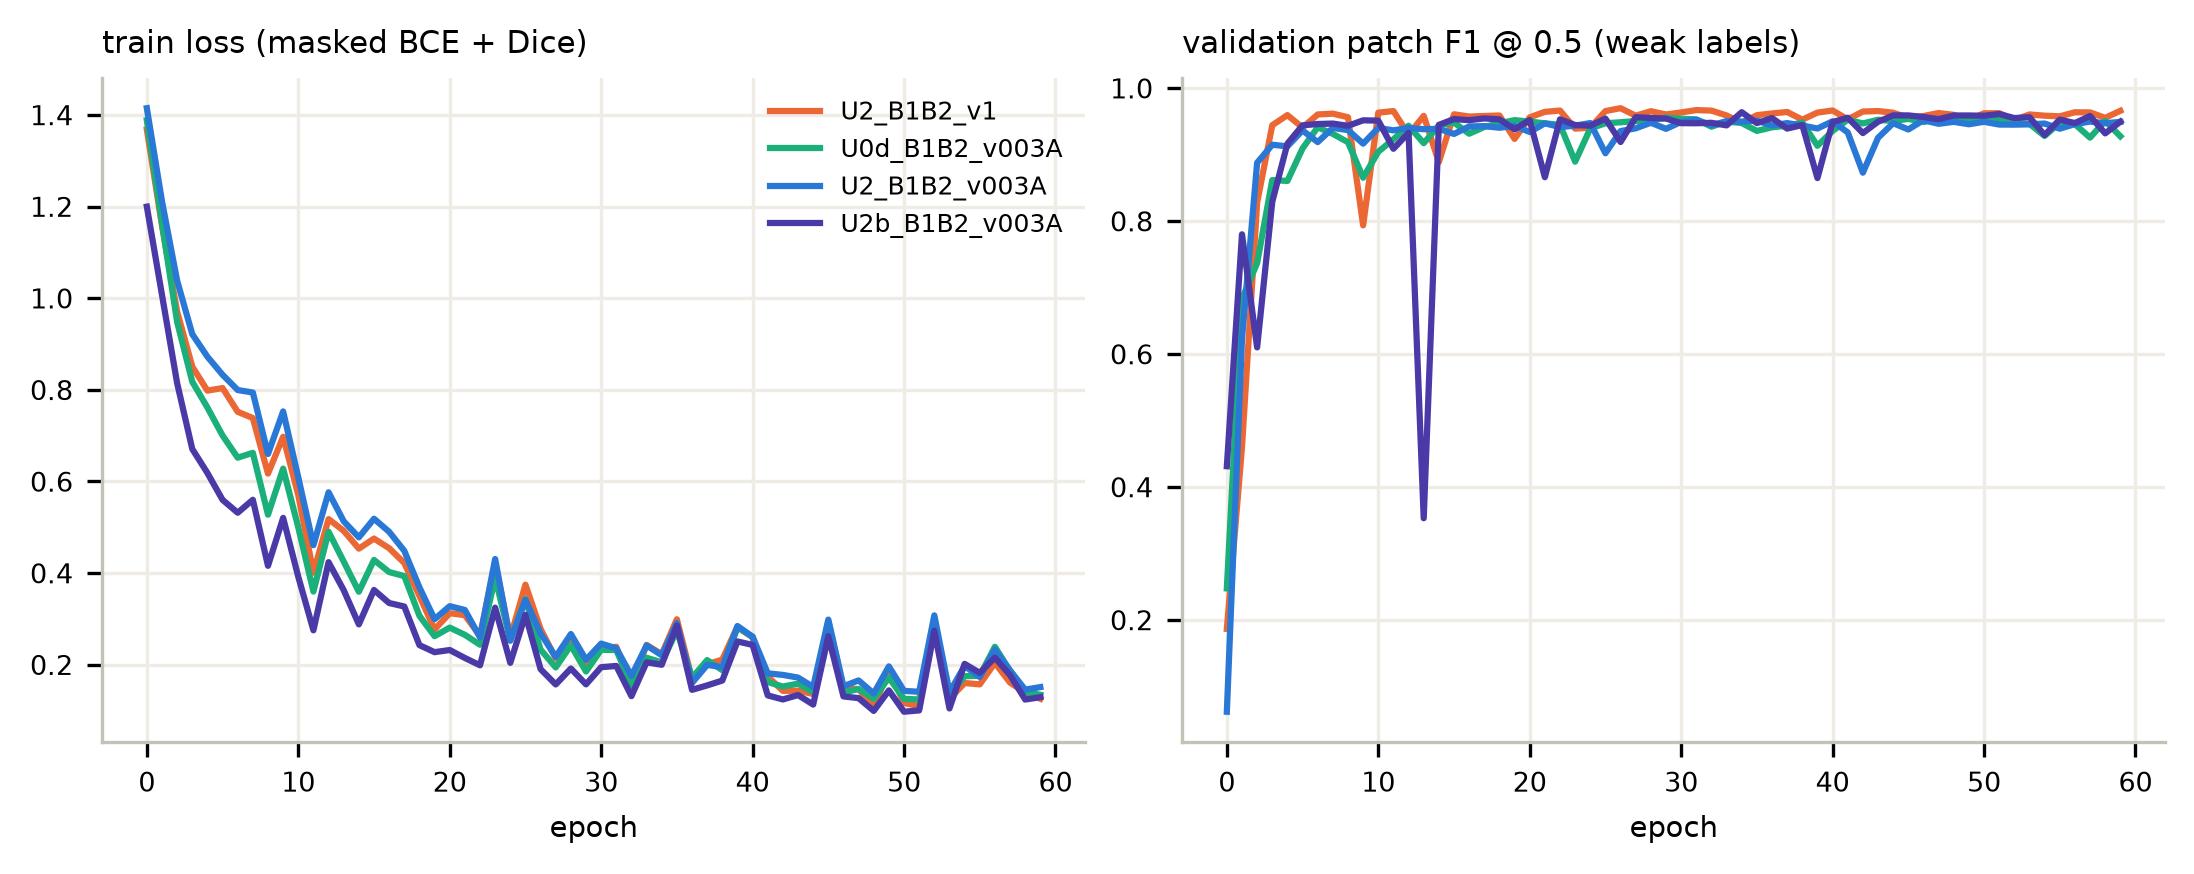

In [5]:
fig('FigS01')

## 4. D1 endpoints with spatial-block bootstrap intervals

In [6]:
e = show('T05'); e[e.endpoint.isin(['G_F1','G_IoU','G_PR_AUC','A_FP_area_dry_cropland_km2','A2_PREDICTED_FLOOD_BURDEN_ON_UNLABELLED_CROPLAND_km2','B_recall_flooded_open_low_veg','W_IoU','BU_FP_area_km2'])].pivot_table(index=['arm','labels'], columns='endpoint', values='value')

**T05** [weak_label_agreement] D1 endpoints per arm on the frozen TEST blocks with 95 % spatial-block bootstrap intervals (2000 resamples).

endpoint    A2_PREDICTED_FLOOD_BURDEN_ON_UNLABELLED_CROPLAND_km2  A_FP_area_dry_cropland_km2  BU_FP_area_km2  B_recall_flooded_open_low_veg    G_F1   G_IoU  G_PR_AUC   W_IoU
arm labels                                                                                                                                                                   
U0d v002                                              21.2084                         0.5488          0.3864                         0.7330  0.9452  0.8961    0.9807  0.9570
    v003_A                                             7.5603                         0.4306          0.3692                         0.6901  0.9287  0.8669    0.9698  0.9355
U0z v002                                              17.3523                         0.1258          0.2055                         0.7134  0.9533  0.9108    0.9816  0.9588
U1  v002                                              23.9220                         0.6091          0.0553                         0.8404  0.9622  0.9272    0.9888  0.9689
U2  v002                                              11.6800                         0.1153          0.8047                         0.7764  0.9375  0.8823    0.9780  0.9484
    v003_A                                             4.0625                         0.1560          0.2975                         0.6458  0.9306  0.8702    0.9613  0.9456
U2b v003_A                                             1.4672                         0.0662          0.4922                         0.6917  0.9365  0.8805    0.9724  0.9486

## 5. Paired comparisons (identical blocks)

In [7]:
p = show('T06'); p[p.endpoint.isin(['A2_PREDICTED_FLOOD_BURDEN_ON_UNLABELLED_CROPLAND_km2','B_recall_flooded_open_low_veg','G_F1','BU_FP_area_km2'])]

**T06** [weak_label_agreement] Paired arm comparisons (B minus A) on identical spatial blocks, 2000 resamples, 95 % intervals.

,comparison,labels,endpoint,median,ci_lo,ci_hi,excludes_zero,independent,note
3,U0z - U0d,v002,B_recall_flooded_open_low_veg,-0.01860,-0.042900,0.000200,False,weak-label,NaN
13,U0z - U0d,v002,BU_FP_area_km2,-0.17670,-0.457618,-0.003300,True,weak-label,NaN
16,U0z - U0d,v002,G_F1,0.00765,0.000600,0.060902,True,weak-label,NaN
22,U0z - U0d,v002,A2_PREDICTED_FLOOD_BURDEN_ON_UNLABELLED_CROPLA...,-3.74535,-9.932835,2.249097,False,weak-label,NaN
31,U1 - U0d,v002,B_recall_flooded_open_low_veg,0.10575,0.005698,0.371602,True,weak-label,NaN
41,U1 - U0d,v002,BU_FP_area_km2,-0.32120,-0.831800,-0.006300,True,weak-label,NaN
44,U1 - U0d,v002,G_F1,0.01650,-0.006702,0.025100,False,weak-label,NaN
50,U1 - U0d,v002,A2_PREDICTED_FLOOD_BURDEN_ON_UNLABELLED_CROPLA...,2.59915,-1.916290,9.323620,False,weak-label,NaN
59,U2 - U0d,v002,B_recall_flooded_open_low_veg,0.04280,-0.005100,0.175900,False,weak-label,NaN
69,U2 - U0d,v002,BU_FP_area_km2,0.37005,0.038398,1.025718,True,weak-label,NaN


In [8]:
show('T07b')

**T07b** [weak_label_agreement] Paired differences (B minus A) of the v003_A attribution endpoints across label sets and inputs.

,A,B,endpoint,median,lo,hi,excludes_zero,independent
0,U2_B1B2_v1,U2_B1B2_v003A,R_pred_on_reference_water_km2,-13.41275,-29.52655,-2.45226,True,weak-label
1,U2_B1B2_v1,U2_B1B2_v003A,R_pred_on_reference_water_wpre_water_km2,-13.08275,-29.18553,-2.39700,True,weak-label
2,U2_B1B2_v1,U2_B1B2_v003A,R_pred_on_reference_water_wpre_dry_km2,-0.25490,-0.71302,-0.01640,True,weak-label
3,U2_B1B2_v1,U2_B1B2_v003A,R_frac_reference_water_above_thr,-0.09737,-0.14481,-0.02741,True,weak-label
4,U2_B1B2_v1,U2_B1B2_v003A,R_reference_water_evaluated_km2,0.00000,0.00000,0.00000,False,weak-label
5,U2_B1B2_v1,U2_B1B2_v003A,E_recall_event_flood,-0.02760,-0.04160,0.00620,False,weak-label
6,U2_B1B2_v1,U2_B1B2_v003A,E_FN_km2,1.13785,-0.01560,3.19471,False,weak-label
7,U2_B1B2_v1,U2_B1B2_v003A,E_reference_km2,0.00000,0.00000,0.00000,False,weak-label
8,U2_B1B2_v1,U2_B1B2_v003A,L_FP_on_land_km2,-1.96795,-5.05441,0.06957,False,weak-label
9,U2_B1B2_v1,U2_B1B2_v003A,L_FP_rate_land,-0.00394,-0.01145,0.00013,False,weak-label


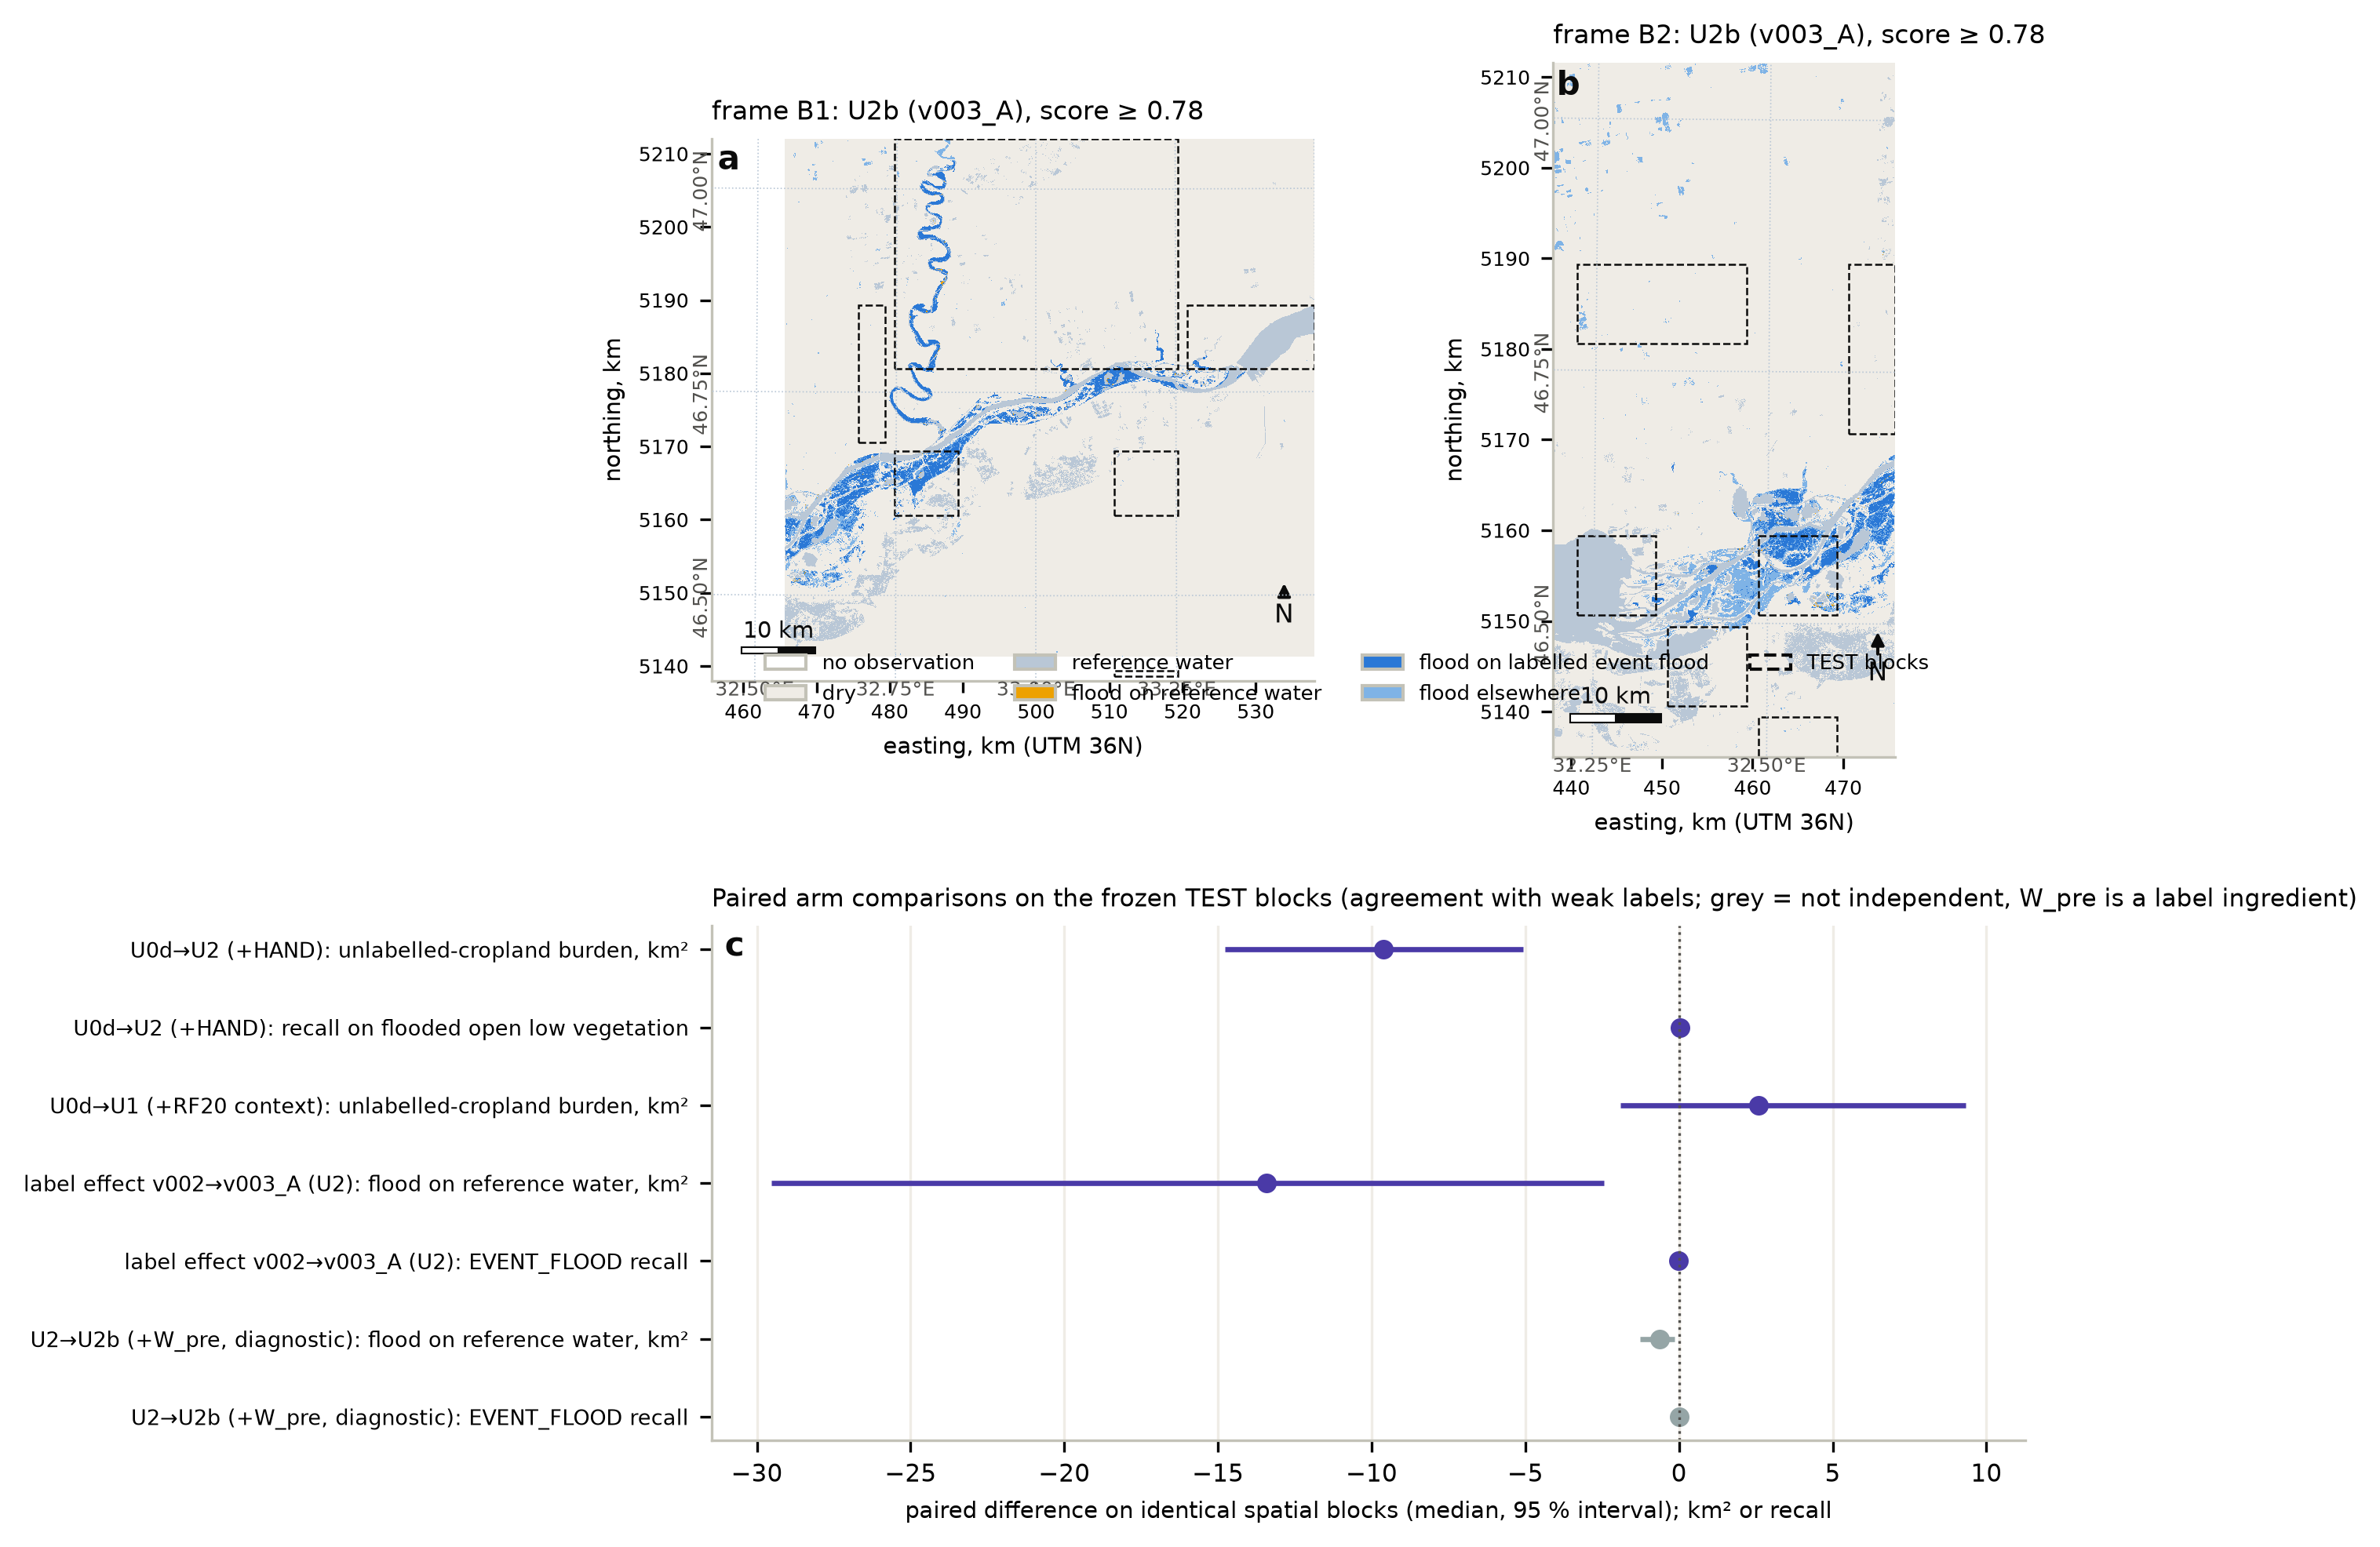

In [9]:
fig('Fig03')

## 6. Cropland-associated SAR candidates (audit)
Wording rule: none of the audited candidates showed positive evidence consistent with breach-induced inundation under the available SAR, optical and terrain constraints.

In [10]:
show('T08'); show('T08b')

**T08** [weak_label_agreement] Cropland-associated SAR candidates (p89 audit): groups A (water before the breach), B (wet/irrigated agriculture), D (unresolved / likely SAR artefact) per arm and frame.

**T08b** [weak_label_agreement] Retention of U0d candidate area by the other v002 arms (fraction of km2).

,group,U0d_area_km2,retained_km2_U0z,retained_km2_U1,retained_km2_U2,retention_U0z,retention_U1,retention_U2
0,A,7.292,2.963,5.687,3.156,0.406,0.780,0.433
1,B,8.020,5.684,6.838,4.373,0.709,0.853,0.545
2,D,3.865,3.366,3.525,2.143,0.871,0.912,0.555


## 7. Block-size sensitivity

**T20** [weak_label_agreement] Block-size sensitivity (U2 on v003_A): the same recipe on splits with 7.5, 10 (frozen), 15 and 20 km blocks; each split has its own TEST geography, so only the endpoint values and intervals are compared, never differences.

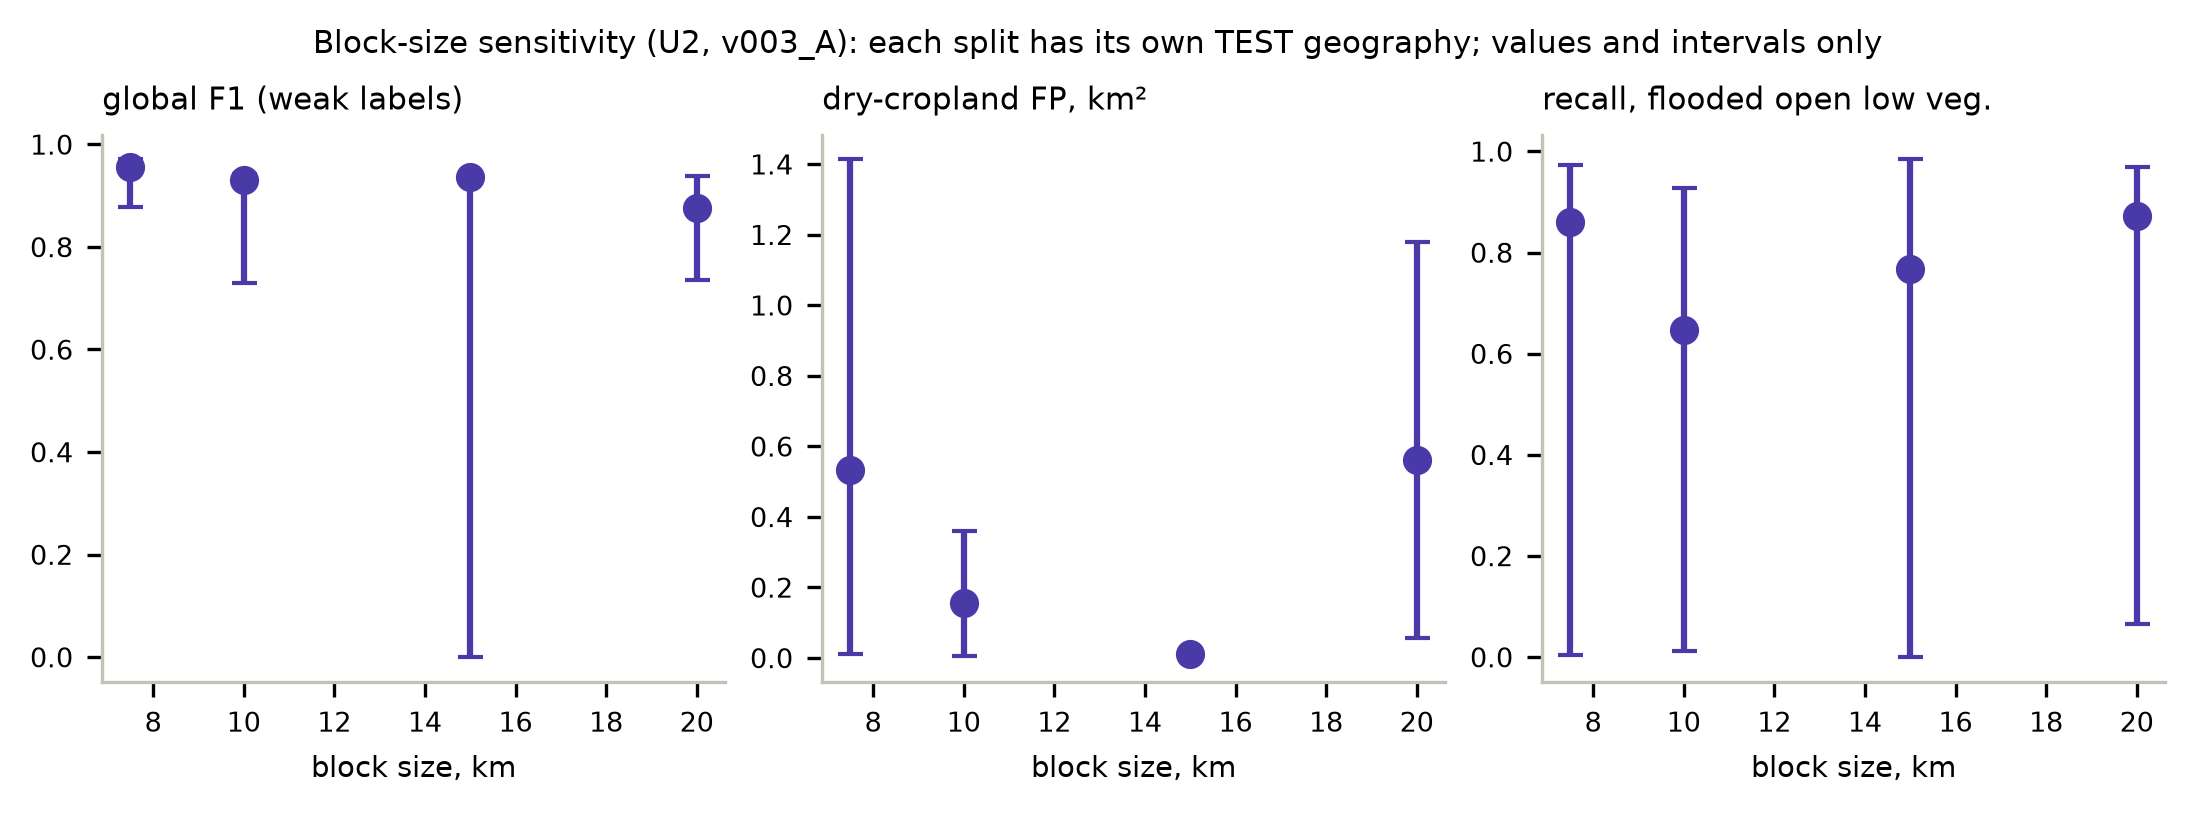

In [11]:
show('T20'); fig('FigS05')